# Polynomial Regression

When the relationship between features and target is non-linear, linear models underperform. Polynomial Regression resolves this by adding powers of original features as new inputs. This notebook covers:
*   Generating polynomial features using `PolynomialFeatures`.
*   Transforming train and test sets to avoid data leakage.
*   Fitting a polynomial model and assessing performance.

In [8]:
import pandas as pd 
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model   import LinearRegression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt  


In [105]:
poly=PolynomialFeatures(degree=2)
model= LinearRegression()

### Note:
* poly.fit_tranform(x_train)# It learns the pattern 
* poly.transform(x_test) # used for unseen data
* It is a  preprocessing technique which helps to handle non linear data pattern by adding extra feature with the help of degree.
* When ever we fit a model with features(input columns) the same number features(columns) should be passed to test the model
* example: feature:3(columns) target:1(columns)
           for testing the model we should pass 3 columns or else we will get an error

In [106]:
df=pd.read_csv("Ice_cream selling dataset.csv")

In [107]:
df.head()

,Temperature (°C),Ice Cream Sales (units)
0,-4.662263,41.842986
1,-4.316559,34.661120
2,-4.213985,39.383001
3,-3.949661,37.539845
4,-3.578554,32.284531


In [108]:
df.shape

(49, 2)

In [109]:
x=df[['Temperature (°C)']]
y=df['Ice Cream Sales (units)']

In [110]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [111]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(39, 1)
(10, 1)
(39,)
(10,)


In [112]:
updated_x_train=poly.fit_transform(x_train)
updated_x_test=poly.transform(x_test)

In [113]:
updated_x_train.shape

(39, 3)

In [114]:
y_train.shape

(39,)

In [115]:
model.fit(updated_x_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [116]:
x_test

,Temperature (°C)
13,-1.818938
45,3.704057
47,4.133534
44,3.610778
17,-0.773330
27,1.024181
26,0.874905
25,0.693599
31,1.850552
19,-0.149635


In [117]:
y_test

13    10.012868
45    17.843957
47    27.698383
44    28.912188
17     9.392969
27     2.313806
26     0.789974
25     4.625689
31     4.857988
19     4.673643
Name: Ice Cream Sales (units), dtype: float64

In [118]:
updated_x_test

array([[ 1.        , -1.81893761,  3.30853403],
       [ 1.        ,  3.70405744, 13.72004151],
       [ 1.        ,  4.13353379, 17.08610158],
       [ 1.        ,  3.61077848, 13.03772121],
       [ 1.        , -0.77333004,  0.59803936],
       [ 1.        ,  1.02418081,  1.04894634],
       [ 1.        ,  0.87490503,  0.76545881],
       [ 1.        ,  0.69359887,  0.4810794 ],
       [ 1.        ,  1.85055193,  3.42454243],
       [ 1.        , -0.14963487,  0.02239059]])

In [119]:
y_pred_degree_2=model.predict(updated_x_train)

In [120]:
from sklearn.metrics import r2_score
r_2_degree_2=r2_score(y_train,y_pred_degree_2)
print(r_2_degree_2)

0.9413665676490518


In [121]:
df.corr()

,Temperature (°C),Ice Cream Sales (units)
Temperature (°C),1.000000,-0.175184
Ice Cream Sales (units),-0.175184,1.000000


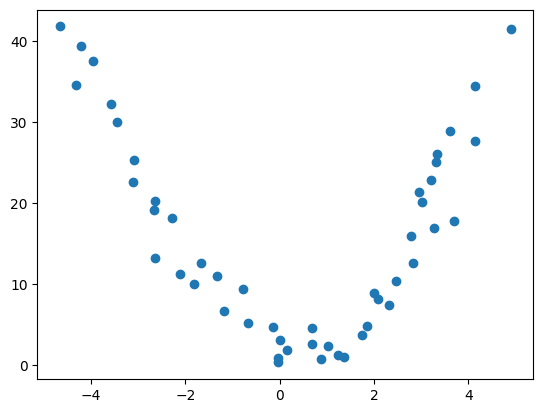

In [122]:
plt.scatter(df['Temperature (°C)'],df['Ice Cream Sales (units)'])

In [22]:
import pandas as pd
df=pd.read_csv("data.csv")

In [23]:
df.head(1)

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,2014-05-02 00:00:00,313000.0,3.0,1.5,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA


In [25]:
x=df.select_dtypes(include="number")
y=df["price"]

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
0,313000.0,3.0,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005
1,2384000.0,5.0,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0
2,342000.0,3.0,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0
3,420000.0,3.0,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0
4,550000.0,4.0,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992


In [27]:
xtrain,xtest,ytrain,ytest=train_test_split(x,y,train_size=0.8,random_state=42)

In [34]:
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
STscaler=StandardScaler()
RoScaler=RobustScaler()
MinScaler=MinMaxScaler()
model=LinearRegression()
updated_xtrain_ST=STscaler.fit_transform(xtrain)
updated_xtest_ST=STscaler.transform(xtest)
updated_xtrain_RO=RoScaler.fit_transform(xtrain)
updated_xtest_RO=RoScaler.transform(xtest)
updated_xtrain_Min=MinScaler.fit_transform(xtrain)
updated_xtest_Min=MinScaler.transform(xtest)


In [ ]:
print(updated_xtrain_ST)
model.fit(updated_xtrain_ST,ytrain)
ypred_train_ST=model.predict(updated_xtest_ST)



[[ 0.37181164  0.67051991  0.43690203 ... -0.67958227  0.62672137
  -0.82244584]
 [ 0.82811426  0.67051991  1.07491769 ... -0.67958227  0.6939252
  -0.82244584]
 [ 0.34528242  0.67051991  0.43690203 ... -0.67958227  0.39150796
  -0.82244584]
 ...
 [-0.67609263 -0.43006585 -1.47714495 ... -0.33515114 -1.28858778
   1.17817606]
 [ 0.14631325 -1.5306516  -1.47714495 ... -0.67958227 -2.36384905
   1.22619916]
 [-0.18530202 -1.5306516  -1.47714495 ...  0.6766153  -1.38939352
  -0.82244584]]


In [37]:
test_score=model.score(updated_xtest_ST,ytest)
train_score=model.score(updated_xtrain_ST,ytrain)
print(test_score,train_score)

1.0 1.0


In [ ]:
model.predict()

In [30]:
print(updated_xtrain_RO)


[[ 0.66364556  1.          0.33333333 ...  0.          0.30434783
   0.        ]
 [ 1.17898206  1.          1.         ...  0.          0.34782609
   0.        ]
 [ 0.63368413  1.          0.33333333 ...  0.          0.15217391
   0.        ]
 ...
 [-0.51983072  0.         -1.66666667 ...  0.26229508 -0.93478261
   0.97948974]
 [ 0.40897345 -1.         -1.66666667 ...  0.         -1.63043478
   1.0030015 ]
 [ 0.03445564 -1.         -1.66666667 ...  1.03278689 -1.
   0.        ]]


In [31]:
print(updated_xtrain_Min)

[[0.09699115 0.44444444 0.37037037 ... 0.         0.78070175 0.        ]
 [0.12134513 0.44444444 0.44444444 ... 0.         0.79824561 0.        ]
 [0.09557522 0.44444444 0.37037037 ... 0.         0.71929825 0.        ]
 ...
 [0.04106195 0.33333333 0.14814815 ... 0.03319502 0.28070175 0.97219464]
 [0.08495575 0.22222222 0.14814815 ... 0.         0.         0.99553128]
 [0.06725664 0.22222222 0.14814815 ... 0.13070539 0.25438596 0.        ]]
